In [1]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.variant_index import VariantIndex
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f

Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/21 14:45:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
path_to_release_folder = "../../data/25.06/"
path_to_intermediate_data_folder = "../../data/intermediate_files/"

sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set")
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")

disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path = path_to_release_folder + "output/evidence/sourceId=chembl"
chembl_evidence = session.spark.read.parquet(platform_chembl_evidence_path)

all_evidence = session.spark.read.parquet(path_to_release_folder + "output/evidence")


efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
    disease_index_orig=disease_index_orig,
    efo_ids="MONDO_0045024",
)

chembl_evidence.show(1)

l2g_full = session.spark.read.parquet(path_to_intermediate_data_folder + "l2g_full_for_enrichment/")
l2g_full.count()

l2g_full.show(1)


g_p_s = session.spark.read.parquet(path_to_intermediate_data_folder + "genes_therapeutic_areas")
g_p_s.count()

26/01/21 14:45:44 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------+----------------+---------------+----------+--------+-------------------+----------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+----------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+-----------------+-----------------------

8285

# With measurments data


In [ ]:
combined_evidence = session.spark.read.csv(
    path_to_intermediate_data_folder + "combined_evidence_with_measurements.csv", header=True, inferSchema=True
)

In [ ]:
# combined_evidence.write.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/combined_evidence_with_measurements.parquet", mode="overwrite")

In [ ]:
combined_evidence.groupBy("source").count().show()

+-----------------+------+
|           source| count|
+-----------------+------+
|     all_diseases| 36858|
|      gene_burden|  6857|
|             omim|  6596|
|         orphanet|  6192|
| all_measurements|150360|
|           ChEMBL| 25234|
|    cancer_ChEMBL|  8811|
|        gwas_eQTL| 12343|
|    gwas_with_pav|  5441|
|           molQTL| 17755|
|non_cancer_ChEMBL| 16423|
+-----------------+------+



In [ ]:
combined_evidence.select("targetId").distinct().count()

18809

In [ ]:
combined_evidence.filter(~(f.col("source") == "molQTL")).select("targetId").distinct().count()

16479

In [ ]:
combined_evidence.filter(f.col("source").isin(["all_diseases", "all_measurements"])).select(
    "targetId"
).distinct().count()

15641

In [ ]:
combined_evidence.filter(f.col("source").isin(["omim"])).select("targetId").distinct().count()

4182

In [ ]:
target = session.spark.read.csv("./data/target_with_constraints_2509.csv", header=True, inferSchema=True)
target.count()

20083

# Load data without measuments and preparing data


In [ ]:
combined_evidence = session.spark.read.csv(
    path_to_intermediate_data_folder + "combined_evidence_without_measurements.csv", header=True, inferSchema=True
)

In [ ]:
combined_evidence.select("targetId").distinct().count()

11022

In [ ]:
combined_evidence.groupBy("source").count().show()

+-----------------+-----+
|           source|count|
+-----------------+-----+
|     all_diseases|36858|
|    cancer_ChEMBL| 8811|
|      gene_burden| 1777|
|             omim| 6596|
|        gwas_eQTL|12343|
|    gwas_with_pav| 5441|
|         orphanet| 6192|
|           ChEMBL|25229|
|non_cancer_ChEMBL|16418|
+-----------------+-----+



In [ ]:
target = session.spark.read.csv(
    path_to_intermediate_data_folder + "target_with_constraints_2509.csv", header=True, inferSchema=True
)
target.count()

20083

In [ ]:
pleiotropy_combined_evidence = (
    combined_evidence.filter(~(f.col("source").isin(["ChEMBL", "non_cancer_ChEMBL", "cancer_ChEMBL"])))
    .groupBy("targetId")
    .agg(f.countDistinct("diseaseId").alias("unique_disease_count"))
    .cache()
)
pleiotropy_combined_evidence.count()

10734

In [ ]:
pleiotropy_combined_evidence_gwas_only = (
    combined_evidence.filter(f.col("source") == "all_diseases")
    .groupBy("targetId")
    .agg(f.countDistinct("diseaseId").alias("unique_disease_count"))
    .cache()
)
pleiotropy_combined_evidence_gwas_only.count()

26/01/21 14:37:06 WARN CacheManager: Asked to cache already cached data.


8285

In [ ]:
combined_pleiotropy = pleiotropy_combined_evidence.join(
    pleiotropy_combined_evidence_gwas_only.withColumnRenamed("unique_disease_count", "gwas_only_disease_count"),
    on="targetId",
    how="full_outer",
).fillna(0, subset=["unique_disease_count", "gwas_only_disease_count"])

combined_pleiotropy.count()

10734

In [ ]:
combined_pleiotropy.show(1)

+---------------+--------------------+-----------------------+
|       targetId|unique_disease_count|gwas_only_disease_count|
+---------------+--------------------+-----------------------+
|ENSG00000059588|                   1|                      1|
+---------------+--------------------+-----------------------+
only showing top 1 row



In [ ]:
# Pearson correlation between two columns
correlation = combined_pleiotropy.stat.corr("unique_disease_count", "gwas_only_disease_count")
print(f"Pearson correlation: {correlation}")

Pearson correlation: 0.9294964173901605


In [ ]:
# Show top targets with both all-sources and GWAS-only pleiotropy
top_targets_detailed = (
    combined_pleiotropy.orderBy(f.desc("unique_disease_count"))
    .select("targetId", "unique_disease_count", "gwas_only_disease_count")
    .limit(20)
)

top_targets_detailed.show()

+---------------+--------------------+-----------------------+
|       targetId|unique_disease_count|gwas_only_disease_count|
+---------------+--------------------+-----------------------+
|ENSG00000147883|                 148|                    148|
|ENSG00000140718|                 128|                    126|
|ENSG00000168769|                 114|                     34|
|ENSG00000130203|                 111|                    107|
|ENSG00000175164|                 105|                    105|
|ENSG00000171456|                  93|                      5|
|ENSG00000164362|                  93|                     84|
|ENSG00000111252|                  88|                     87|
|ENSG00000166949|                  86|                     82|
|ENSG00000183765|                  84|                     60|
|ENSG00000148737|                  76|                     75|
|ENSG00000134242|                  73|                     71|
|ENSG00000139618|                  71|                 

# Combine with Irene's data


In [ ]:
target.show(1)

+---------------+--------------+----------+----------+----------+
|       targetId|       biotype|syn_constr|mis_constr|lof_constr|
+---------------+--------------+----------+----------+----------+
|ENSG00000000003|protein_coding|  -0.47468|   0.59223|    -0.985|
+---------------+--------------+----------+----------+----------+
only showing top 1 row



In [ ]:
essential_genes = session.spark.read.parquet(path_to_intermediate_data_folder + "annotated_targets_wide.parquet")

In [ ]:
essential_genes.show(1)

+---------------+------------+-------------+--------------+--------------+------------------+----------+------------------+--------------------+-----------+------------------------+--------------------+---------+-------------+-------------+----------------+----------+
|       targetId|pharmacogene|liable_target|withdrawn_drug|essential_gene|mouse_ko_mortality|dd_related|cancer_driver_gene|trial_safety_concern|drug_target|non_oncology_drug_target|oncology_drug_target|inComplex|selectiveGene|non_essential|distant_ortholog|hc_paralog|
+---------------+------------+-------------+--------------+--------------+------------------+----------+------------------+--------------------+-----------+------------------------+--------------------+---------+-------------+-------------+----------------+----------+
|ENSG00000083454|           0|            1|             0|             0|                 0|         0|                 0|                   0|          0|                       0|            

In [ ]:
# essential_genes = session.spark.read.parquet("gs://ot-team/irene/cautionary_targets/cautionary_targets_wide.parquet/")

In [ ]:
# essential_genes.count()

In [ ]:
essential_genes = essential_genes.fillna(0)

In [ ]:
essential_genes.show(1)

+---------------+------------+-------------+--------------+--------------+------------------+----------+------------------+--------------------+-----------+------------------------+--------------------+---------+-------------+-------------+----------------+----------+
|       targetId|pharmacogene|liable_target|withdrawn_drug|essential_gene|mouse_ko_mortality|dd_related|cancer_driver_gene|trial_safety_concern|drug_target|non_oncology_drug_target|oncology_drug_target|inComplex|selectiveGene|non_essential|distant_ortholog|hc_paralog|
+---------------+------------+-------------+--------------+--------------+------------------+----------+------------------+--------------------+-----------+------------------------+--------------------+---------+-------------+-------------+----------------+----------+
|ENSG00000083454|           0|            1|             0|             0|                 0|         0|                 0|                   0|          0|                       0|            

In [ ]:
# Define the columns to melt (exclude targetId)
value_columns = [
    "pharmacogene",
    "liable_target",
    "withdrawn_drug",
    "essential_gene",
    "mouse_ko_mortality",
    "dd_related",
    "cancer_driver_gene",
    "trial_safety_concern",
    "inComplex",
    "selectiveGene",
    "non_essential",
    "hc_paralog",
    "distant_ortholog",
]

# Melt the DataFrame
essential_genes_long = essential_genes.select(f.col("targetId"), *[f.col(c) for c in value_columns]).melt(
    ids=["targetId"], values=value_columns, variableColumnName="category", valueColumnName="value"
)

essential_genes_long.count()

109850

In [ ]:
essential_genes_long.show(1)

+---------------+------------+-----+
|       targetId|    category|value|
+---------------+------------+-----+
|ENSG00000083454|pharmacogene|    0|
+---------------+------------+-----+
only showing top 1 row



In [ ]:
essential_genes_long.groupBy("category").count().show(20)

+--------------------+-----+
|            category|count|
+--------------------+-----+
|          hc_paralog| 8450|
|    distant_ortholog| 8450|
|           inComplex| 8450|
|  cancer_driver_gene| 8450|
|      withdrawn_drug| 8450|
|       selectiveGene| 8450|
|      essential_gene| 8450|
|       liable_target| 8450|
|          dd_related| 8450|
|        pharmacogene| 8450|
|trial_safety_concern| 8450|
|  mouse_ko_mortality| 8450|
|       non_essential| 8450|
+--------------------+-----+



In [ ]:
essential_genes_long.groupBy("value").count().show(20)

+-----+-----+
|value|count|
+-----+-----+
|    1|12819|
|    0|97031|
+-----+-----+



In [ ]:
essential_genes_long = essential_genes_long.filter(f.col("value") == 1).drop("value")

In [ ]:
essential_genes_long.groupBy("category").count().show(20)

+--------------------+-----+
|            category|count|
+--------------------+-----+
|          hc_paralog| 1588|
|    distant_ortholog|  831|
|           inComplex| 3566|
|  cancer_driver_gene|  368|
|      withdrawn_drug|  166|
|       selectiveGene|  930|
|      essential_gene| 1489|
|       liable_target|  214|
|          dd_related|  866|
|        pharmacogene|  543|
|trial_safety_concern|  448|
|  mouse_ko_mortality| 1038|
|       non_essential|  772|
+--------------------+-----+



In [ ]:
essential_genes_long.show(1)

+---------------+-------------+
|       targetId|     category|
+---------------+-------------+
|ENSG00000083454|liable_target|
+---------------+-------------+
only showing top 1 row



In [ ]:
essential_genes_long = essential_genes_long.join(target.select("targetId"), on="targetId", how="inner")

In [ ]:
essential_genes_long.groupBy("category").count().show(20)

+--------------------+-----+
|            category|count|
+--------------------+-----+
|          hc_paralog| 1587|
|    distant_ortholog|  830|
|           inComplex| 3530|
|  cancer_driver_gene|  368|
|      withdrawn_drug|  166|
|       selectiveGene|  930|
|      essential_gene| 1489|
|       liable_target|  214|
|          dd_related|  861|
|        pharmacogene|  538|
|trial_safety_concern|  440|
|  mouse_ko_mortality| 1022|
|       non_essential|  766|
+--------------------+-----+



In [ ]:
essential_genes_long = essential_genes_long.withColumnRenamed("category", "source")

In [ ]:
essential_genes_long.show(1)

+---------------+-------------+
|       targetId|       source|
+---------------+-------------+
|ENSG00000083454|liable_target|
+---------------+-------------+
only showing top 1 row



In [ ]:
combined_evidence.show(1)

+---------------+-------------+-------------+--------+
|       targetId|    diseaseId|resourceScore|  source|
+---------------+-------------+-------------+--------+
|ENSG00000064419|MONDO_0012034|          1.0|orphanet|
+---------------+-------------+-------------+--------+
only showing top 1 row



In [ ]:
combined_evidence_all = (
    combined_evidence.select("targetId", "source").unionByName(essential_genes_long).distinct().cache()
)
combined_evidence_all.count()

26/01/21 14:51:41 WARN CacheManager: Asked to cache already cached data.


37842

In [ ]:
all_genes = target.select("targetId").distinct()
all_genes = all_genes.withColumn("source", f.lit("All genes"))
combined_evidence_all = combined_evidence_all.unionByName(all_genes).distinct().cache()

In [ ]:
combined_evidence_all.groupBy("source").count().show()

+------------------+-----+
|            source|count|
+------------------+-----+
|      all_diseases| 8285|
|        hc_paralog| 1587|
|  distant_ortholog|  830|
|     cancer_ChEMBL|  649|
|       gene_burden|  557|
|              omim| 4182|
|         inComplex| 3530|
| non_cancer_ChEMBL|  958|
|     selectiveGene|  930|
|    essential_gene| 1489|
|         gwas_eQTL| 3945|
|     gwas_with_pav| 1574|
|     liable_target|  214|
|          orphanet| 3814|
|            ChEMBL| 1137|
|        dd_related|  861|
|      pharmacogene|  538|
|mouse_ko_mortality| 1022|
|         All genes|20083|
|     non_essential|  766|
+------------------+-----+
only showing top 20 rows



In [ ]:
combined_evidence_all.count()

57925

In [ ]:
combined_evidence_all.toPandas().to_csv(
    path_to_intermediate_data_folder + "combined_evidence_for_constrain_plot.csv", index=False
)

# Plotting - pleiotropy_combined_evidence-OLD


In [ ]:
target = session.spark.read.csv("./data/target_with_constraints_2509.csv", header=True, inferSchema=True)
target.count()

20083

In [ ]:
pleiotropy_combined_evidence = session.spark.read.csv(
    "./data/pleiotropy_combined_evidence.csv", header=True, inferSchema=True
)
pleiotropy_combined_evidence.count()

10734

In [ ]:
pleiotropy_combined_evidence.show(1)

+---------------+--------------------+
|       targetId|unique_disease_count|
+---------------+--------------------+
|ENSG00000196950|                   2|
+---------------+--------------------+
only showing top 1 row



In [ ]:
combined_evidence = session.spark.read.csv(
    "./data/combined_evidence_for_constrain_plot.csv", header=True, inferSchema=True
)

In [ ]:
combined_evidence.count()

50282

In [ ]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|        all_diseases| 8285|
|       cancer_ChEMBL|  649|
|         gene_burden|  557|
|                omim| 4182|
|  cancer_driver_gene|  368|
|      withdrawn_drug|  166|
|   non_cancer_ChEMBL|  958|
|      essential_gene| 1489|
|           gwas_eQTL| 3945|
|       gwas_with_pav| 1574|
|       liable_target|  214|
|            orphanet| 3814|
|              ChEMBL| 1137|
|          dd_related|  861|
|        pharmacogene|  538|
|trial_safety_concern|  440|
|  mouse_ko_mortality| 1022|
|           All genes|20083|
+--------------------+-----+



In [ ]:
# Create mapping dictionary
category_mapping = {
    "all_diseases": "GWAS",
    "cancer_ChEMBL": "Cancer ChEMBL",
    "gene_burden": "Gene-based analysis",
    "omim": "OMIM",
    "cancer_driver_gene": "Cancer Driver (COSMIC)",
    "withdrawn_drug": "Withdrawn Drug",
    "non_cancer_ChEMBL": "Non-Cancer ChEMBL",
    "essential_gene": "Essential Gene (DepMap)",
    "gwas_eQTL": "GWAS with eQTL evidence",
    "gwas_with_pav": "GWAS with PAV evidence",
    "liable_target": "Known safety events",
    "orphanet": "Orphanet",
    "ChEMBL": "ChEMBL",
    "dd_related": "DD panel (gene2phenotype)",
    "pharmacogene": "Pharmacogenetics - Toxicity",
    "trial_safety_concern": "Trial Safety",
    "mouse_ko_mortality": "Mouse KO Mortality",
    "All genes": "All protein-coding genes",
}

# Apply the mapping
from pyspark.sql.functions import col

combined_evidence = combined_evidence.replace(category_mapping, subset=["source"])

In [ ]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|            Orphanet| 3814|
|  Mouse KO Mortality| 1022|
|DD panel (gene2ph...|  861|
|All protein-codin...|20083|
|                GWAS| 8285|
|   Non-Cancer ChEMBL|  958|
|Cancer Driver (CO...|  368|
| Known safety events|  214|
|                OMIM| 4182|
| Gene-based analysis|  557|
|       Cancer ChEMBL|  649|
|        Trial Safety|  440|
|Essential Gene (D...| 1489|
|              ChEMBL| 1137|
|      Withdrawn Drug|  166|
|Pharmacogenetics ...|  538|
|GWAS with eQTL ev...| 3945|
|GWAS with PAV evi...| 1574|
+--------------------+-----+



In [ ]:
combined_evidence.show(1)

+---------------+--------+
|       targetId|  source|
+---------------+--------+
|ENSG00000121075|Orphanet|
+---------------+--------+
only showing top 1 row



In [ ]:
combined_evidence.count()

50282

In [ ]:
combined_evidence = (
    combined_evidence.join(pleiotropy_combined_evidence_gwas_only, on="targetId", how="left")
    .fillna(0, subset=["unique_disease_count"])
    .cache()
)

combined_evidence.count()

25/09/19 23:30:03 WARN CacheManager: Asked to cache already cached data.


50282

In [ ]:
combined_evidence.show(1)

+---------------+--------+--------------------+
|       targetId|  source|unique_disease_count|
+---------------+--------+--------------------+
|ENSG00000121075|Orphanet|                   2|
+---------------+--------+--------------------+
only showing top 1 row



In [ ]:
combined_evidence = combined_evidence.join(target.select("targetId", "lof_constr"), on="targetId", how="left").cache()

combined_evidence.count()

25/09/19 23:30:04 WARN CacheManager: Asked to cache already cached data.


50282

In [ ]:
combined_evidence.show(1)

+---------------+--------+--------------------+----------+
|       targetId|  source|unique_disease_count|lof_constr|
+---------------+--------+--------------------+----------+
|ENSG00000121075|Orphanet|                   2|    -0.379|
+---------------+--------+--------------------+----------+
only showing top 1 row



In [ ]:
combined_evidence = combined_evidence.toPandas()

In [ ]:
combined_evidence = combined_evidence.dropna(subset=["lof_constr"])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Calculate summary statistics by source
summary_stats = (
    combined_evidence.groupby("source")
    .agg({"unique_disease_count": ["mean", "std", "count"], "lof_constr": ["mean", "std", "count"]})
    .reset_index()
)

# Flatten column names
summary_stats.columns = [
    "source",
    "pleiotropy_mean",
    "pleiotropy_std",
    "pleiotropy_count",
    "constraint_mean",
    "constraint_std",
    "constraint_count",
]

# Calculate 95% CI (1.96 * SE)
summary_stats["pleiotropy_se"] = summary_stats["pleiotropy_std"] / np.sqrt(summary_stats["pleiotropy_count"])
summary_stats["pleiotropy_ci"] = 1.96 * summary_stats["pleiotropy_se"]

summary_stats["constraint_se"] = summary_stats["constraint_std"] / np.sqrt(summary_stats["constraint_count"])
summary_stats["constraint_ci"] = 1.96 * summary_stats["constraint_se"]

print(summary_stats.head())

                      source  pleiotropy_mean  pleiotropy_std  \
0   All protein-coding genes         1.992209        4.996152   
1              Cancer ChEMBL         3.553055        7.477045   
2     Cancer Driver (COSMIC)         7.029326       12.456478   
3                     ChEMBL         3.485714        7.129213   
4  DD panel (gene2phenotype)         4.814208        8.893251   

   pleiotropy_count  constraint_mean  constraint_std  constraint_count  \
0             18097        -0.996385        0.461632             18097   
1               622        -0.802921        0.430066               622   
2               341        -0.527085        0.361256               341   
3              1085        -0.805877        0.434695              1085   
4               732        -0.495642        0.370554               732   

   pleiotropy_se  pleiotropy_ci  constraint_se  constraint_ci  
0       0.037139       0.072793       0.003432       0.006726  
1       0.299802       0.587612     

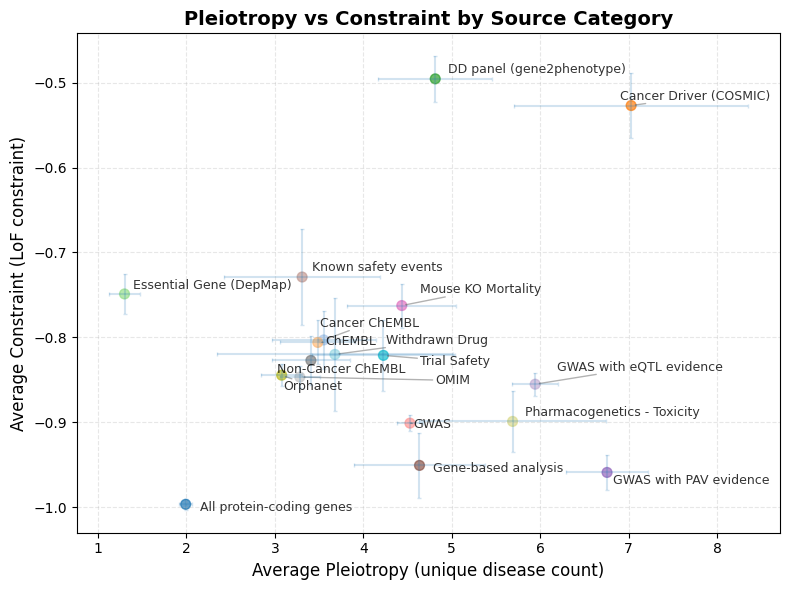

In [ ]:
# First install: pip install adjustText
from adjustText import adjust_text

# Create 2D scatter plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot each source category as a point
scatter = ax.scatter(
    summary_stats["pleiotropy_mean"],
    summary_stats["constraint_mean"],
    s=50,
    alpha=0.7,
    c=range(len(summary_stats)),
    cmap="tab20",
)

# Add error bars
ax.errorbar(
    summary_stats["pleiotropy_mean"],
    summary_stats["constraint_mean"],
    xerr=summary_stats["pleiotropy_ci"],
    yerr=summary_stats["constraint_ci"],
    fmt="none",
    capsize=1.5,
    capthick=1,
    alpha=0.2,
)

# Create text annotations
texts = []
for i, row in summary_stats.iterrows():
    txt = ax.annotate(row["source"], (row["pleiotropy_mean"], row["constraint_mean"]), fontsize=9, alpha=0.8)
    texts.append(txt)

# Adjust text positions to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", alpha=0.6))

ax.set_xlabel("Average Pleiotropy (unique disease count)", fontsize=12)
ax.set_ylabel("Average Constraint (LoF constraint)", fontsize=12)
ax.set_title("Pleiotropy vs Constraint by Source Category", fontsize=14, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.3)
# ax.set_xlim(3, 5)  # Set x-axis from 0 to 5
# ax.set_ylim(-1, -0.7)  # Set y-axis from 0 to 2

plt.tight_layout()
plt.show()

# Plotting - pleiotropy_combined_evidence_gwas_only-OLD


In [ ]:
target = session.spark.read.csv("./data/target_with_constraints_2509.csv", header=True, inferSchema=True)
target.count()

20083

In [ ]:
pleiotropy_combined_evidence = session.spark.read.csv(
    "./data/pleiotropy_combined_evidence_gwas_only.csv", header=True, inferSchema=True
)
pleiotropy_combined_evidence.count()

8285

In [ ]:
pleiotropy_combined_evidence.show(1)

+---------------+--------------------+
|       targetId|unique_disease_count|
+---------------+--------------------+
|ENSG00000196950|                   2|
+---------------+--------------------+
only showing top 1 row



In [ ]:
g_p_s = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/genes_therapeutic_areas"
)

In [ ]:
combined_evidence = session.spark.read.csv(
    "./data/combined_evidence_for_constrain_plot.csv", header=True, inferSchema=True
)

In [ ]:
combined_evidence.count()

60511

In [ ]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|        all_diseases| 8285|
|          hc_paralog| 4173|
|    distant_ortholog|  830|
|       cancer_ChEMBL|  649|
|         gene_burden|  557|
|                omim| 4182|
|           inComplex| 3530|
|  cancer_driver_gene|  368|
|      withdrawn_drug|  166|
|   non_cancer_ChEMBL|  958|
|       selectiveGene|  930|
|      essential_gene| 1489|
|           gwas_eQTL| 3945|
|       gwas_with_pav| 1574|
|       liable_target|  214|
|            orphanet| 3814|
|              ChEMBL| 1137|
|          dd_related|  861|
|        pharmacogene|  538|
|trial_safety_concern|  440|
+--------------------+-----+
only showing top 20 rows



In [ ]:
combined_evidence.show(1)

+---------------+--------+
|       targetId|  source|
+---------------+--------+
|ENSG00000121075|orphanet|
+---------------+--------+
only showing top 1 row



In [ ]:
gwas_genes = combined_evidence.filter(f.col("source") == "all_diseases").select("targetId").distinct()
# combined_evidence=combined_evidence.join(gwas_genes, on="targetId", how="inner")

In [ ]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|        all_diseases| 8285|
|          hc_paralog| 4173|
|    distant_ortholog|  830|
|       cancer_ChEMBL|  649|
|         gene_burden|  557|
|                omim| 4182|
|           inComplex| 3530|
|  cancer_driver_gene|  368|
|      withdrawn_drug|  166|
|   non_cancer_ChEMBL|  958|
|       selectiveGene|  930|
|      essential_gene| 1489|
|           gwas_eQTL| 3945|
|       gwas_with_pav| 1574|
|       liable_target|  214|
|            orphanet| 3814|
|              ChEMBL| 1137|
|          dd_related|  861|
|        pharmacogene|  538|
|trial_safety_concern|  440|
+--------------------+-----+
only showing top 20 rows



In [ ]:
# Create mapping dictionary
category_mapping = {
    "all_diseases": "GWAS",
    "cancer_ChEMBL": "Cancer ChEMBL",
    "gene_burden": "Gene-based analysis",
    "omim": "OMIM",
    "cancer_driver_gene": "Cancer Driver (COSMIC)",
    "withdrawn_drug": "Withdrawn Drug",
    "non_cancer_ChEMBL": "Non-Cancer ChEMBL",
    "essential_gene": "Essential Gene (DepMap)",
    "gwas_eQTL": "GWAS with eQTL evidence",
    "gwas_with_pav": "GWAS with PAV evidence",
    "liable_target": "Known safety events",
    "orphanet": "Orphanet",
    "ChEMBL": "ChEMBL",
    "dd_related": "DD panel (gene2phenotype)",
    "pharmacogene": "Pharmacogenetics - Toxicity",
    "trial_safety_concern": "Trial Safety",
    "mouse_ko_mortality": "Mouse KO Mortality",
    "All genes": "All protein-coding genes",
}

# Apply the mapping
from pyspark.sql.functions import col

combined_evidence = combined_evidence.replace(category_mapping, subset=["source"])

In [ ]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|          hc_paralog| 4173|
|            Orphanet| 3814|
|    distant_ortholog|  830|
|  Mouse KO Mortality| 1022|
|DD panel (gene2ph...|  861|
|All protein-codin...|20083|
|           inComplex| 3530|
|                GWAS| 8285|
|   Non-Cancer ChEMBL|  958|
|Cancer Driver (CO...|  368|
| Known safety events|  214|
|                OMIM| 4182|
| Gene-based analysis|  557|
|       selectiveGene|  930|
|       Cancer ChEMBL|  649|
|        Trial Safety|  440|
|Essential Gene (D...| 1489|
|              ChEMBL| 1137|
|      Withdrawn Drug|  166|
|Pharmacogenetics ...|  538|
+--------------------+-----+
only showing top 20 rows



In [ ]:
combined_evidence.show(1)

+---------------+--------+
|       targetId|  source|
+---------------+--------+
|ENSG00000121075|Orphanet|
+---------------+--------+
only showing top 1 row



In [ ]:
combined_evidence.count()

60511

In [ ]:
g_p_s = g_p_s.withColumnRenamed("geneId", "targetId")
g_p_s.show(1)

+---------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+-----------------+------------------+
|       targetId|uniqueDiseases|uniqueTherapeuticAreas|maxEQTLColoc|maxPQTLColoc|maxVEP|maxDistanceTSS|minEffectiveSampleSize|maxEffectiveSampleSize|earliestPublicati

In [ ]:
combined_evidence = (
    combined_evidence.join(g_p_s.select("targetId", "uniqueDiseases", "pathwayCount"), on="targetId", how="left")
    .fillna(0, subset=["uniqueDiseases", "pathwayCount"])
    .cache()
)

combined_evidence.count()

60511

In [ ]:
combined_evidence.show(1)

+---------------+--------+--------------+------------+
|       targetId|  source|uniqueDiseases|pathwayCount|
+---------------+--------+--------------+------------+
|ENSG00000121075|Orphanet|             2|           0|
+---------------+--------+--------------+------------+
only showing top 1 row



In [ ]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|          hc_paralog| 4173|
|            Orphanet| 3814|
|    distant_ortholog|  830|
|  Mouse KO Mortality| 1022|
|DD panel (gene2ph...|  861|
|All protein-codin...|20083|
|           inComplex| 3530|
|                GWAS| 8285|
|   Non-Cancer ChEMBL|  958|
|Cancer Driver (CO...|  368|
| Known safety events|  214|
|                OMIM| 4182|
| Gene-based analysis|  557|
|       selectiveGene|  930|
|       Cancer ChEMBL|  649|
|        Trial Safety|  440|
|Essential Gene (D...| 1489|
|              ChEMBL| 1137|
|      Withdrawn Drug|  166|
|Pharmacogenetics ...|  538|
+--------------------+-----+
only showing top 20 rows



In [ ]:
combined_evidence = combined_evidence.join(target.select("targetId", "lof_constr"), on="targetId", how="left").cache()

combined_evidence.count()

60511

In [ ]:
combined_evidence.show(1)

+---------------+--------+--------------+------------+----------+
|       targetId|  source|uniqueDiseases|pathwayCount|lof_constr|
+---------------+--------+--------------+------------+----------+
|ENSG00000121075|Orphanet|             2|           0|    -0.379|
+---------------+--------+--------------+------------+----------+
only showing top 1 row



In [ ]:
combined_evidence.groupBy("source").count().show()

+--------------------+-----+
|              source|count|
+--------------------+-----+
|          hc_paralog| 4173|
|            Orphanet| 3814|
|    distant_ortholog|  830|
|  Mouse KO Mortality| 1022|
|DD panel (gene2ph...|  861|
|All protein-codin...|20083|
|           inComplex| 3530|
|                GWAS| 8285|
|   Non-Cancer ChEMBL|  958|
|Cancer Driver (CO...|  368|
| Known safety events|  214|
|                OMIM| 4182|
| Gene-based analysis|  557|
|       selectiveGene|  930|
|       Cancer ChEMBL|  649|
|        Trial Safety|  440|
|Essential Gene (D...| 1489|
|              ChEMBL| 1137|
|      Withdrawn Drug|  166|
|Pharmacogenetics ...|  538|
+--------------------+-----+
only showing top 20 rows



In [ ]:
combined_evidence_pd = combined_evidence.toPandas()

In [ ]:
combined_evidence_pd

,targetId,source,uniqueDiseases,pathwayCount,lof_constr
0,ENSG00000121075,Orphanet,2,0,-0.379
1,ENSG00000149970,Orphanet,7,7,NaN
2,ENSG00000111837,Orphanet,3,0,-0.894
3,ENSG00000184156,Orphanet,2,2,-0.458
4,ENSG00000135249,Orphanet,0,0,-0.931
...,...,...,...,...,...
60506,ENSG00000253731,hc_paralog,0,0,-0.834
60507,ENSG00000088986,distant_ortholog,0,0,-0.744
60508,ENSG00000107937,distant_ortholog,0,0,-0.405
60509,ENSG00000150316,distant_ortholog,0,0,-0.658


In [ ]:
disease_genes = [row.targetId for row in gwas_genes.collect()]

In [61]:
len(disease_genes)

8285

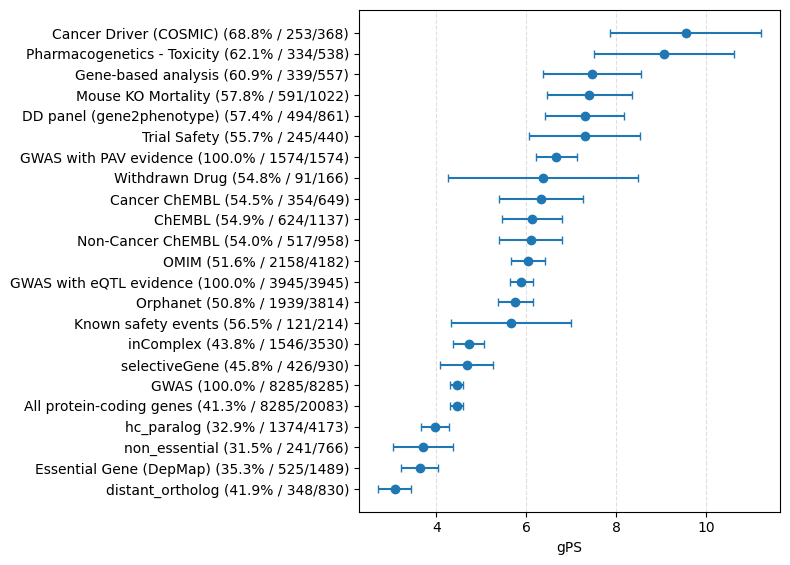

,source,N_total,N_overlap,mean_uniqueDiseases,ci95
0,Cancer Driver (COSMIC),368,253,9.541502,1.676440
1,Pharmacogenetics - Toxicity,538,334,9.059880,1.558529
2,Gene-based analysis,557,339,7.466077,1.091097
3,Mouse KO Mortality,1022,591,7.397631,0.947425
4,DD panel (gene2phenotype),861,494,7.301619,0.877399
5,Trial Safety,440,245,7.297959,1.241769
6,GWAS with PAV evidence,1574,1574,6.668996,0.453061
7,Withdrawn Drug,166,91,6.373626,2.120617
8,Cancer ChEMBL,649,354,6.319209,0.937685
9,ChEMBL,1137,624,6.126603,0.667269


In [ ]:
# Python
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ensure disease_genes set exists
if "disease_genes" in globals():
    disease_set = set(disease_genes)
elif "gwas_genes" in globals():
    disease_set = set([r.targetId for r in gwas_genes.collect()])
else:
    raise RuntimeError("Provide disease_genes list or have gwas_genes Spark DF in scope")

# keep relevant columns and deduplicate per source,targetId
df = combined_evidence_pd[["source", "targetId", "uniqueDiseases"]].dropna(subset=["source", "targetId"])
df = df.drop_duplicates(["source", "targetId"]).copy()

# totals per category
totals = df.groupby("source").agg(N_total=("targetId", "nunique")).reset_index()

# overlap rows and stats (mean, std, count)
df["in_disease"] = df["targetId"].isin(disease_set)
overlap = (
    df[df["in_disease"]]
    .groupby("source")
    .agg(
        N_overlap=("targetId", "nunique"),
        mean_uniqueDiseases=("uniqueDiseases", "mean"),
        std_uniqueDiseases=("uniqueDiseases", "std"),
        n=("uniqueDiseases", "count"),
    )
    .reset_index()
)

# merge and compute SE & 95% CI
stats = totals.merge(overlap, on="source", how="left").fillna(
    {"N_overlap": 0, "mean_uniqueDiseases": np.nan, "std_uniqueDiseases": np.nan, "n": 0}
)
stats["se"] = stats["std_uniqueDiseases"] / np.sqrt(stats["n"].replace(0, np.nan))
stats["ci95"] = 1.96 * stats["se"]

# add formatted label with percent and counts
stats["pct"] = 100 * stats["N_overlap"] / stats["N_total"]
stats["label"] = stats.apply(
    lambda r: f"{r['source']} ({r['pct']:.1f}% / {int(r['N_overlap'])}/{int(r['N_total'])})", axis=1
)

# order by mean desc (NaN go last)
stats_sorted = stats.sort_values("mean_uniqueDiseases", ascending=False, na_position="last").reset_index(drop=True)

# plotting horizontal
fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * len(stats_sorted))))
y = np.arange(len(stats_sorted))

# plot only categories with non-null mean
mask = stats_sorted["mean_uniqueDiseases"].notna()
ax.errorbar(
    stats_sorted.loc[mask, "mean_uniqueDiseases"],
    y[mask],
    xerr=stats_sorted.loc[mask, "ci95"],
    fmt="o",
    capsize=3,
    color="C0",
)

# optionally mark categories without overlap (no mean) with a small cross at x=0
mask_no = ~mask
if mask_no.any():
    ax.scatter([0] * mask_no.sum(), y[mask_no], marker="x", color="gray", alpha=0.6, label="no overlap")

ax.set_yticks(y)
ax.set_yticklabels(stats_sorted["label"])
ax.invert_yaxis()
ax.set_xlabel("gPS")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# inspect resulting table
stats_sorted[["source", "N_total", "N_overlap", "mean_uniqueDiseases", "ci95"]].head(100)

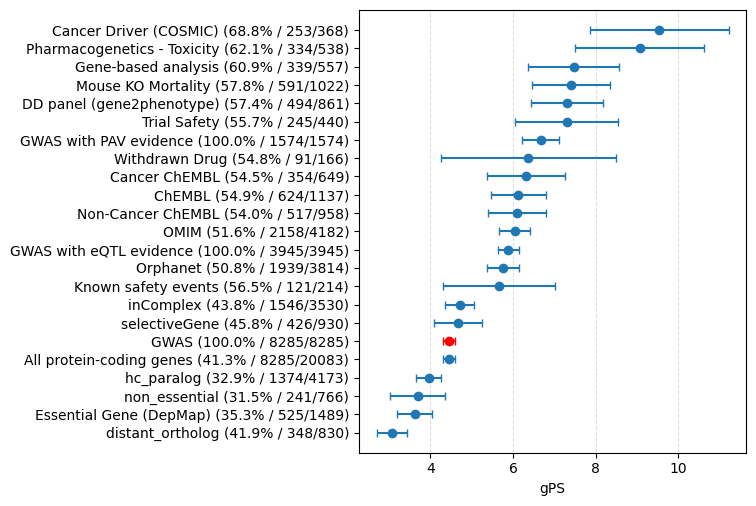

In [ ]:
# ...existing code...
# plotting horizontal (highlight GWAS in red)
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(5, max(4, 0.25 * len(stats_sorted))))
y = np.arange(len(stats_sorted))

ax.set_yticks(y)
ax.set_yticklabels(stats_sorted["label"])
ax.invert_yaxis()
ax.set_xlabel("gPS")
ax.grid(axis="x", linestyle="--", alpha=0.4)

# plot points with errorbars individually so we can colour GWAS red
for i, row in stats_sorted.iterrows():
    if pd.isna(row["mean_uniqueDiseases"]):
        continue
    color = "red" if str(row["source"]) == "GWAS" else "C0"
    ax.errorbar(row["mean_uniqueDiseases"], i, xerr=row["ci95"], fmt="o", color=color, capsize=3)

# mark categories without overlap (no mean) with a gray cross at x=0
no_mask = stats_sorted["mean_uniqueDiseases"].isna()
if no_mask.any():
    ax.scatter([0] * no_mask.sum(), y[no_mask], marker="x", color="gray", alpha=0.6, label="no overlap")

# legend with GWAS highlighted
gw_patch = mpatches.Patch(color="red", label="GWAS")
other_patch = mpatches.Patch(color="C0", label="Other sources")
# ax.legend(handles=[gw_patch, other_patch], loc='lower right')

In [ ]:
# ...existing code...
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# build disease set
if "disease_genes" in globals():
    disease_set = set(disease_genes)
elif "gwas_genes" in globals():
    disease_set = set([r.targetId for r in gwas_genes.collect()])
else:
    raise RuntimeError("Provide disease_genes list or have gwas_genes Spark DF in scope")

# prepare dataframe
df = (
    combined_evidence_pd[["source", "targetId", "uniqueDiseases"]]
    .dropna(subset=["source", "targetId", "uniqueDiseases"])
    .drop_duplicates(["source", "targetId"])
    .copy()
)

# restrict to overlap with disease_genes
df_overlap = df[df["targetId"].isin(disease_set)].copy()

# ensure GWAS exists
if "GWAS" not in df["source"].unique():
    raise RuntimeError("No 'GWAS' source found in 'source' column; check category naming.")

# collect arrays per source
groups = {src: grp["uniqueDiseases"].values for src, grp in df_overlap.groupby("source")}

gw = groups.get("GWAS", np.array([]))

results = []
for src, vals in groups.items():
    if src == "GWAS":
        continue
    n1 = len(gw)
    n2 = len(vals)
    mean1 = np.nanmean(gw) if n1 > 0 else np.nan
    mean2 = np.nanmean(vals) if n2 > 0 else np.nan
    std1 = np.nanstd(gw, ddof=1) if n1 > 1 else np.nan
    std2 = np.nanstd(vals, ddof=1) if n2 > 1 else np.nan
    if n1 < 2 or n2 < 2:
        tstat = np.nan
        pval = np.nan
    else:
        tstat, pval = ttest_ind(gw, vals, equal_var=False, nan_policy="omit")
    results.append(
        {
            "source": src,
            "n_gwas": n1,
            "n_source": n2,
            "mean_gwas": mean1,
            "mean_source": mean2,
            "std_gwas": std1,
            "std_source": std2,
            "t_stat": tstat,
            "p_value": pval,
        }
    )

res_df = pd.DataFrame(results).sort_values("p_value", na_position="last").reset_index(drop=True)

In [ ]:
res_df

,source,n_gwas,n_source,mean_gwas,mean_source,std_gwas,std_source,t_stat,p_value
0,GWAS with eQTL evidence,8285,3945,4.448763,5.885932,6.635319,8.270875,-9.548422,1.825296e-21
1,GWAS with PAV evidence,8285,1574,4.448763,6.668996,6.635319,9.170718,-9.160281,1.302157e-19
2,OMIM,8285,2158,4.448763,6.041705,6.635319,9.021127,-7.679592,2.192034e-14
3,distant_ortholog,8285,348,4.448763,3.068966,6.635319,3.480015,6.889141,1.850816e-11
4,Orphanet,8285,1939,4.448763,5.759670,6.635319,8.689875,-6.231199,5.417461e-10
5,DD panel (gene2phenotype),8285,494,4.448763,7.301619,6.635319,9.949575,-6.290071,6.741012e-10
6,Mouse KO Mortality,8285,591,4.448763,7.397631,6.635319,11.751203,-6.032307,2.786282e-09
7,Cancer Driver (COSMIC),8285,253,4.448763,9.541502,6.635319,13.604798,-5.932640,9.644815e-09
8,Pharmacogenetics - Toxicity,8285,334,4.448763,9.059880,6.635319,14.532226,-5.774706,1.745319e-08
9,Gene-based analysis,8285,339,4.448763,7.466077,6.635319,10.249601,-5.374292,1.407379e-07


In [ ]:
# ...existing code...
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# build disease set
if "disease_genes" in globals():
    disease_set = set(disease_genes)
elif "gwas_genes" in globals():
    disease_set = set([r.targetId for r in gwas_genes.collect()])
else:
    raise RuntimeError("Provide disease_genes list or have gwas_genes Spark DF in scope")

# prepare dataframe and restrict to overlap
df = (
    combined_evidence_pd[["source", "targetId", "uniqueDiseases"]]
    .dropna(subset=["source", "targetId", "uniqueDiseases"])
    .drop_duplicates(["source", "targetId"])
    .copy()
)
df_overlap = df[df["targetId"].isin(disease_set)].copy()

# ensure GWAS exists (mapped name in notebook is 'GWAS')
if "GWAS" not in df_overlap["source"].unique():
    raise RuntimeError("No 'GWAS' source found in 'source' column; check category naming.")

# collect arrays per source (drop NA)
groups = {src: grp["uniqueDiseases"].dropna().values for src, grp in df_overlap.groupby("source")}
gw = groups.get("GWAS", np.array([]))

results = []
for src, vals in groups.items():
    if src == "GWAS":
        continue
    n_gw = len(gw)
    n_src = len(vals)
    mean_gw = np.nanmean(gw) if n_gw > 0 else np.nan
    mean_src = np.nanmean(vals) if n_src > 0 else np.nan
    std_gw = np.nanstd(gw, ddof=1) if n_gw > 1 else np.nan
    std_src = np.nanstd(vals, ddof=1) if n_src > 1 else np.nan

    if n_gw < 2 or n_src < 2:
        tstat = np.nan
        pval = np.nan
    else:
        # Student's t-test (assume equal variances)
        tstat, pval = ttest_ind(gw, vals, equal_var=True, nan_policy="omit")

    results.append(
        {
            "source": src,
            "n_gwas": n_gw,
            "n_source": n_src,
            "mean_gwas": mean_gw,
            "mean_source": mean_src,
            "std_gwas": std_gw,
            "std_source": std_src,
            "t_stat": tstat,
            "p_value": pval,
        }
    )

res_df = pd.DataFrame(results).sort_values("p_value", na_position="last").reset_index(drop=True)

In [ ]:
res_df

,source,n_gwas,n_source,mean_gwas,mean_source,std_gwas,std_source,t_stat,p_value
0,Pharmacogenetics - Toxicity,8285,334,4.448763,9.059880,6.635319,14.532226,-11.628041,5.056532e-31
1,Cancer Driver (COSMIC),8285,253,4.448763,9.541502,6.635319,13.604798,-11.494570,2.348097e-30
2,GWAS with PAV evidence,8285,1574,4.448763,6.668996,6.635319,9.170718,-11.371506,8.885369e-30
3,GWAS with eQTL evidence,8285,3945,4.448763,5.885932,6.635319,8.270875,-10.313798,7.715845e-25
4,Mouse KO Mortality,8285,591,4.448763,7.397631,6.635319,11.751203,-9.767493,2.013276e-22
5,OMIM,8285,2158,4.448763,6.041705,6.635319,9.021127,-9.162803,6.004806e-20
6,DD panel (gene2phenotype),8285,494,4.448763,7.301619,6.635319,9.949575,-8.974039,3.450078e-19
7,Gene-based analysis,8285,339,4.448763,7.466077,6.635319,10.249601,-7.992091,1.497910e-15
8,Orphanet,8285,1939,4.448763,5.759670,6.635319,8.689875,-7.348938,2.150672e-13
9,Trial Safety,8285,245,4.448763,7.297959,6.635319,9.916712,-6.510030,7.937853e-11


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# build disease set
if "disease_genes" in globals():
    disease_set = set(disease_genes)
elif "gwas_genes" in globals():
    disease_set = set([r.targetId for r in gwas_genes.collect()])
else:
    raise RuntimeError("Provide disease_genes list or have gwas_genes Spark DF in scope")

# prepare deduplicated df (one row per source,targetId)
df = (
    combined_evidence_pd[["source", "targetId", "uniqueDiseases"]]
    .dropna(subset=["source", "targetId", "uniqueDiseases"])
    .drop_duplicates(["source", "targetId"])
    .copy()
)

# restrict to genes in disease_set (overlap only)
df_overlap = df[df["targetId"].isin(disease_set)].copy()

# mapping targetId -> measurement (use a single value per target)
vals_by_target = df_overlap.drop_duplicates("targetId").set_index("targetId")["uniqueDiseases"]

# universe of ids to compare against
universe_ids = vals_by_target.index.values

# ensure GWAS present (name used in notebook = 'GWAS')
if "GWAS" not in df_overlap["source"].unique():
    raise RuntimeError("No 'GWAS' source found in 'source' column; check category naming.")

results = []
sources = sorted(df_overlap["source"].unique())
for src in sources:
    if src == "GWAS":
        continue
    # subset ids belonging to this source (in the overlap)
    subset_ids = np.unique(df_overlap.loc[df_overlap["source"] == src, "targetId"].values)
    # complement = all universe ids minus subset ids
    complement_ids = np.setdiff1d(universe_ids, subset_ids, assume_unique=True)

    # get numeric arrays of the measurement (drop any missing)
    subset_vals = vals_by_target.reindex(subset_ids).dropna().values
    complement_vals = vals_by_target.reindex(complement_ids).dropna().values

    n_sub = len(subset_vals)
    n_cmp = len(complement_vals)
    mean_sub = np.nanmean(subset_vals) if n_sub > 0 else np.nan
    mean_cmp = np.nanmean(complement_vals) if n_cmp > 0 else np.nan
    std_sub = np.nanstd(subset_vals, ddof=1) if n_sub > 1 else np.nan
    std_cmp = np.nanstd(complement_vals, ddof=1) if n_cmp > 1 else np.nan

    if n_sub < 2 or n_cmp < 2:
        tstat = np.nan
        pval = np.nan
    else:
        # Student's t-test (assume equal variances)
        tstat, pval = ttest_ind(subset_vals, complement_vals, equal_var=False, nan_policy="omit")

    results.append(
        {
            "source": src,
            "n_subset": n_sub,
            "n_complement": n_cmp,
            "mean_subset": mean_sub,
            "mean_complement": mean_cmp,
            "std_subset": std_sub,
            "std_complement": std_cmp,
            "t_stat": tstat,
            "p_value": pval,
        }
    )

res_df = pd.DataFrame(results).sort_values("p_value", na_position="last").reset_index(drop=True)

In [ ]:
res_df

,source,n_subset,n_complement,mean_subset,mean_complement,std_subset,std_complement,t_stat,p_value
0,GWAS with eQTL evidence,3945,4340,5.885932,3.142396,8.270875,4.276942,18.686838,1.036205e-75
1,GWAS with PAV evidence,1574,6711,6.668996,3.928029,9.170718,5.762982,11.344055,6.787398e-29
2,OMIM,2158,6127,6.041705,3.887710,9.021127,5.447352,10.441745,4.705340e-25
3,Orphanet,1939,6346,5.759670,4.048219,8.689875,5.807894,8.135002,6.429972e-16
4,distant_ortholog,348,7937,3.068966,4.509260,3.480015,6.733604,-7.155738,3.219790e-12
5,DD panel (gene2phenotype),494,7791,7.301619,4.267873,9.949575,6.325001,6.691818,5.730514e-11
6,Mouse KO Mortality,591,7694,7.397631,4.222251,11.751203,6.008313,6.504140,1.621304e-10
7,Cancer Driver (COSMIC),253,8032,9.541502,4.288347,13.604798,6.226059,6.121539,3.473766e-09
8,Pharmacogenetics - Toxicity,334,7951,9.059880,4.255062,14.532226,6.008367,6.020940,4.522295e-09
9,Gene-based analysis,339,7946,7.466077,4.320035,10.249601,6.405602,5.604912,4.233999e-08


In [ ]:
import numpy as np
import pandas as pd

# build disease set (same as before)
if "disease_genes" in globals():
    disease_set = set(disease_genes)
elif "gwas_genes" in globals():
    disease_set = set([r.targetId for r in gwas_genes.collect()])
else:
    raise RuntimeError("Provide disease_genes list or have gwas_genes Spark DF in scope")

# prepare deduplicated df (one row per source,targetId)
df = (
    combined_evidence_pd[["source", "targetId", "uniqueDiseases"]]
    .dropna(subset=["source", "targetId", "uniqueDiseases"])
    .drop_duplicates(["source", "targetId"])
    .copy()
)

# restrict to genes in disease_set (overlap only)
df_overlap = df[df["targetId"].isin(disease_set)].copy()

# mapping targetId -> measurement (one value per target)
vals_by_target = df_overlap.drop_duplicates("targetId").set_index("targetId")["uniqueDiseases"].dropna()
universe_vals = vals_by_target.values  # x in your example

# ensure GWAS present (name used in notebook = 'GWAS')
if "GWAS" not in df_overlap["source"].unique():
    raise RuntimeError("No 'GWAS' source found in 'source' column; check category naming.")

# permutation test parameters
n_perm = 20000
rng = np.random.default_rng(42)

results = []
sources = sorted(df_overlap["source"].unique())
for src in sources:
    if src == "GWAS":
        continue

    # ids in this source (within the overlap)
    subset_ids = np.unique(df_overlap.loc[df_overlap["source"] == src, "targetId"].values)
    subset_vals = vals_by_target.reindex(subset_ids).dropna().values

    n_sub = len(subset_vals)
    n_univ = len(universe_vals)

    if n_sub < 1 or n_sub > n_univ:
        # cannot perform permutation
        results.append(
            {
                "source": src,
                "n_subset": n_sub,
                "mean_subset": np.nan,
                "mean_universe": np.nan,
                "obs_diff": np.nan,
                "p_value_perm": np.nan,
                "perm_mean": np.nan,
                "perm_std": np.nan,
            }
        )
        continue

    mean_univ = universe_vals.mean()
    mean_sub = subset_vals.mean()
    obs_diff = mean_sub - mean_univ

    # perform permutations: sample subsets of size n_sub from universe_vals without replacement
    perm_diffs = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        sample = rng.choice(universe_vals, size=n_sub, replace=False)
        perm_diffs[i] = sample.mean() - mean_univ

    # two-sided empirical p-value
    p_val = np.mean(np.abs(perm_diffs) >= abs(obs_diff))

    results.append(
        {
            "source": src,
            "n_subset": n_sub,
            "n_universe": n_univ,
            "mean_subset": mean_sub,
            "mean_universe": mean_univ,
            "obs_diff": obs_diff,
            "p_value_perm": p_val,
            "perm_mean": perm_diffs.mean(),
            "perm_std": perm_diffs.std(ddof=1),
        }
    )

res_df = pd.DataFrame(results).sort_values("p_value_perm", na_position="last").reset_index(drop=True)

In [ ]:
res_df

,source,n_subset,n_universe,mean_subset,mean_universe,obs_diff,p_value_perm,perm_mean,perm_std
0,Mouse KO Mortality,591,8285,7.397631,4.448763,2.948868,0.0000,0.001493,0.262646
1,Pharmacogenetics - Toxicity,334,8285,9.059880,4.448763,4.611117,0.0000,-0.005005,0.360929
2,Orphanet,1939,8285,5.759670,4.448763,1.310907,0.0000,-0.000291,0.131257
3,OMIM,2158,8285,6.041705,4.448763,1.592942,0.0000,0.000573,0.123479
4,Non-Cancer ChEMBL,517,8285,6.096712,4.448763,1.647949,0.0000,-0.001702,0.282613
5,Trial Safety,245,8285,7.297959,4.448763,2.849196,0.0000,0.003252,0.420273
6,GWAS with eQTL evidence,3945,8285,5.885932,4.448763,1.437169,0.0000,0.000066,0.076816
7,Gene-based analysis,339,8285,7.466077,4.448763,3.017314,0.0000,-0.001324,0.357005
8,DD panel (gene2phenotype),494,8285,7.301619,4.448763,2.852857,0.0000,-0.005920,0.288565
9,ChEMBL,624,8285,6.126603,4.448763,1.677840,0.0000,0.001092,0.257838


In [ ]:
# ...existing code...
# Benjamini-Hochberg FDR on permutation p-values (fixed)
p = res_df["p_value_perm"].to_numpy(dtype=float)
mask = ~np.isnan(p)
adj_full = np.full_like(p, np.nan, dtype=float)

if mask.sum() > 0:
    pvals = p[mask]
    m = pvals.size
    order = np.argsort(pvals)  # indices that sort pvals ascending
    sorted_p = pvals[order]
    ranks = np.arange(1, m + 1)
    q = sorted_p * m / ranks  # raw BH adjusted (not yet monotonic)
    # enforce monotonicity: take cumulative minimum from largest rank to smallest
    q_adj = np.minimum.accumulate(q[::-1])[::-1]
    q_adj = np.clip(q_adj, 0, 1)
    # map adjusted back to the masked original order
    adj_masked = np.empty_like(q_adj)
    adj_masked[order] = q_adj
    adj_full[mask] = adj_masked

res_df["p_adj_bh"] = adj_full
# ...existing code...

In [ ]:
res_df

,source,n_subset,n_universe,mean_subset,mean_universe,obs_diff,p_value_perm,perm_mean,perm_std,p_adj_bh
0,Mouse KO Mortality,591,8285,7.397631,4.448763,2.948868,0.00000,-0.001362,0.262120,0.000000
1,Pharmacogenetics - Toxicity,334,8285,9.059880,4.448763,4.611117,0.00000,0.002259,0.354161,0.000000
2,Orphanet,1939,8285,5.759670,4.448763,1.310907,0.00000,-0.000230,0.130892,0.000000
3,OMIM,2158,8285,6.041705,4.448763,1.592942,0.00000,-0.000807,0.122991,0.000000
4,Non-Cancer ChEMBL,517,8285,6.096712,4.448763,1.647949,0.00000,0.001658,0.281174,0.000000
5,Trial Safety,245,8285,7.297959,4.448763,2.849196,0.00000,-0.001306,0.417593,0.000000
6,GWAS with eQTL evidence,3945,8285,5.885932,4.448763,1.437169,0.00000,0.000032,0.076399,0.000000
7,Gene-based analysis,339,8285,7.466077,4.448763,3.017314,0.00000,-0.002772,0.351619,0.000000
8,DD panel (gene2phenotype),494,8285,7.301619,4.448763,2.852857,0.00000,-0.000898,0.290479,0.000000
9,ChEMBL,624,8285,6.126603,4.448763,1.677840,0.00000,-0.000325,0.256454,0.000000


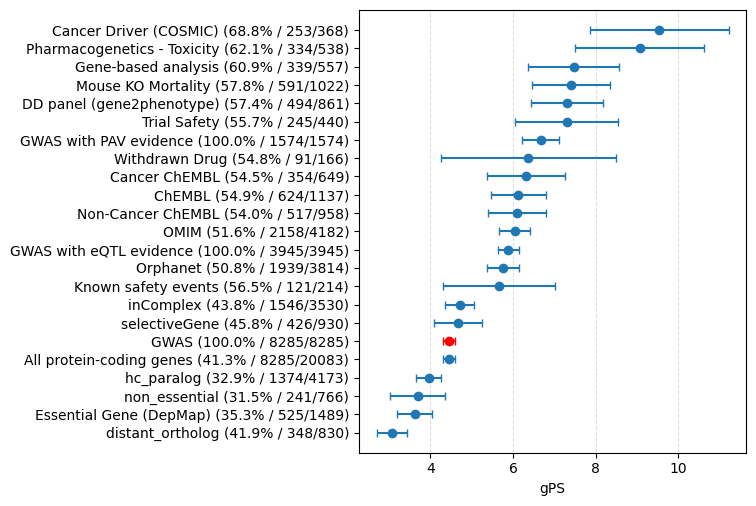

In [ ]:
# ...existing code...
# plotting horizontal (highlight GWAS in red)
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(5, max(4, 0.25 * len(stats_sorted))))
y = np.arange(len(stats_sorted))

ax.set_yticks(y)
ax.set_yticklabels(stats_sorted["label"])
ax.invert_yaxis()
ax.set_xlabel("gPS")
ax.grid(axis="x", linestyle="--", alpha=0.4)

# plot points with errorbars individually so we can colour GWAS red
for i, row in stats_sorted.iterrows():
    if pd.isna(row["mean_uniqueDiseases"]):
        continue
    color = "red" if str(row["source"]) == "GWAS" else "C0"
    ax.errorbar(row["mean_uniqueDiseases"], i, xerr=row["ci95"], fmt="o", color=color, capsize=3)

# mark categories without overlap (no mean) with a gray cross at x=0
no_mask = stats_sorted["mean_uniqueDiseases"].isna()
if no_mask.any():
    ax.scatter([0] * no_mask.sum(), y[no_mask], marker="x", color="gray", alpha=0.6, label="no overlap")

# legend with GWAS highlighted
gw_patch = mpatches.Patch(color="red", label="GWAS")
other_patch = mpatches.Patch(color="C0", label="Other sources")
# ax.legend(handles=[gw_patch, other_patch], loc='lower right')

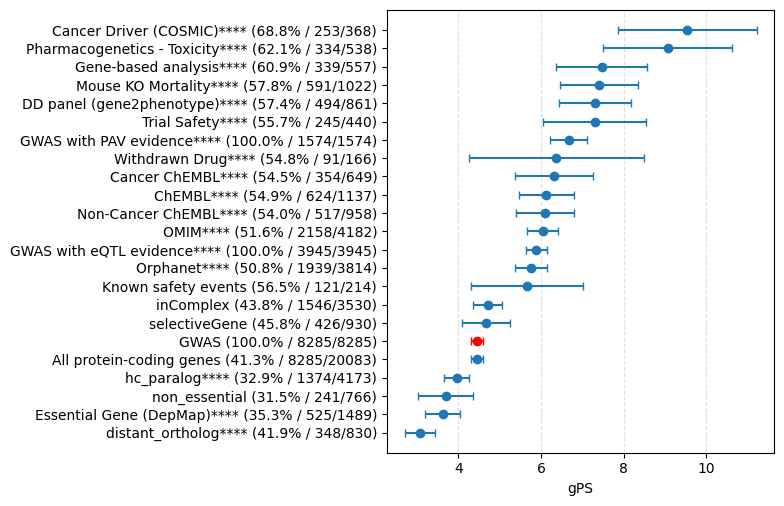

25/11/07 22:40:15 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 989191 ms exceeds timeout 120000 ms
25/11/07 22:40:15 WARN SparkContext: Killing executors is not supported by current scheduler.
25/11/07 22:41:09 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [ ]:
# ...existing code...
import matplotlib.patches as mpatches

# determine significant sources (BH-adjusted p <= 0.05) — keep robust if res_df missing
if "res_df" in globals():
    sig_sources = set(res_df.loc[res_df["p_adj_bh"] <= 0.05, "source"].dropna().astype(str))
else:
    sig_sources = set()


# add '*' to the category name in the label if significant
def add_star_to_label(label: str, source: str) -> str:
    try:
        s = str(source)
        if s in sig_sources:
            return label.replace(s, f"{s}***")
    except Exception:
        pass
    return label


stats_sorted["label"] = stats_sorted.apply(lambda r: add_star_to_label(r["label"], r["source"]), axis=1)

fig, ax = plt.subplots(figsize=(5, max(4, 0.25 * len(stats_sorted))))
y = np.arange(len(stats_sorted))

ax.set_yticks(y)
ax.set_yticklabels(stats_sorted["label"])
ax.invert_yaxis()
ax.set_xlabel("gPS")
ax.grid(axis="x", linestyle="--", alpha=0.4)

# plot points with errorbars individually so we can colour GWAS red
for i, row in stats_sorted.iterrows():
    if pd.isna(row["mean_uniqueDiseases"]):
        continue
    color = "red" if str(row["source"]) == "GWAS" else "C0"
    ax.errorbar(row["mean_uniqueDiseases"], i, xerr=row["ci95"], fmt="o", color=color, capsize=3)

# mark categories without overlap (no mean) with a gray cross at x=0
no_mask = stats_sorted["mean_uniqueDiseases"].isna()
if no_mask.any():
    ax.scatter([0] * no_mask.sum(), y[no_mask], marker="x", color="gray", alpha=0.6, label="no overlap")

# legend with GWAS highlighted
gw_patch = mpatches.Patch(color="red", label="GWAS")
other_patch = mpatches.Patch(color="C0", label="Other sources")
# ax.legend(handles=[gw_patch, other_patch], loc='lower right')
# ...existing code...

In [ ]:
combined_evidence_pd = combined_evidence_pd.dropna(subset=["lof_constr"])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Calculate summary statistics by source
summary_stats = (
    combined_evidence_pd.groupby("source")
    .agg({"uniqueDiseases": ["mean", "std", "count"], "lof_constr": ["mean", "std", "count"]})
    .reset_index()
)

# Flatten column names
summary_stats.columns = [
    "source",
    "pleiotropy_mean",
    "pleiotropy_std",
    "pleiotropy_count",
    "constraint_mean",
    "constraint_std",
    "constraint_count",
]

# Calculate 95% CI (1.96 * SE)
summary_stats["pleiotropy_se"] = summary_stats["pleiotropy_std"] / np.sqrt(summary_stats["pleiotropy_count"])
summary_stats["pleiotropy_ci"] = 1.96 * summary_stats["pleiotropy_se"]

summary_stats["constraint_se"] = summary_stats["constraint_std"] / np.sqrt(summary_stats["constraint_count"])
summary_stats["constraint_ci"] = 1.96 * summary_stats["constraint_se"]

In [ ]:
to_exclude = ["Gene-based analysis", "OMIM", "Orphanet", "ChEMBL", "All protein-coding genes"]

In [ ]:
summary_stats = summary_stats[~summary_stats["source"].isin(to_exclude)]

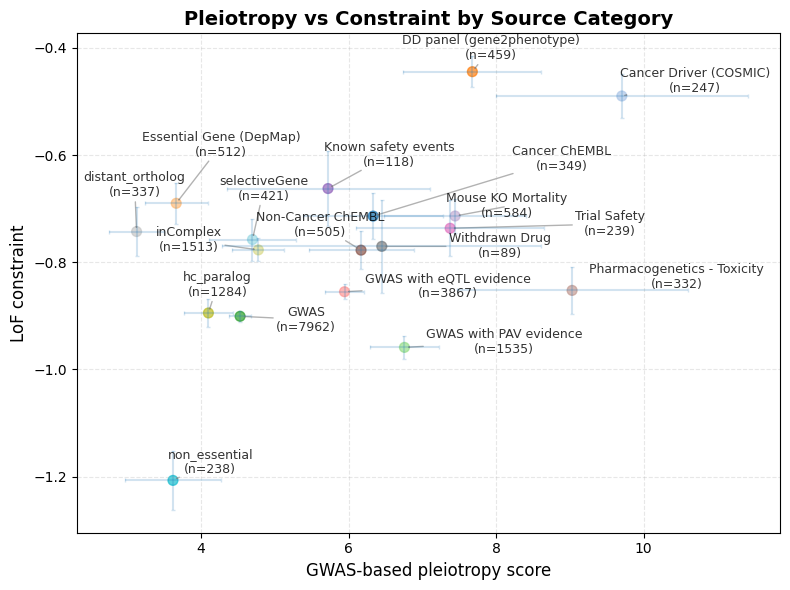

In [ ]:
# First install: pip install adjustText
from adjustText import adjust_text

# Create 2D scatter plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot each source category as a point
scatter = ax.scatter(
    summary_stats["pleiotropy_mean"],
    summary_stats["constraint_mean"],
    s=50,
    alpha=0.7,
    c=range(len(summary_stats)),
    cmap="tab20",
)

# Add error bars
ax.errorbar(
    summary_stats["pleiotropy_mean"],
    summary_stats["constraint_mean"],
    xerr=summary_stats["pleiotropy_ci"],
    yerr=summary_stats["constraint_ci"],
    fmt="none",
    capsize=1.5,
    capthick=1,
    alpha=0.2,
)

# Create text annotations with gene counts
texts = []
for i, row in summary_stats.iterrows():
    # Format the label to include source name and gene count
    label = f"{row['source']}\n(n={int(row['pleiotropy_count'])})"
    txt = ax.annotate(label, (row["pleiotropy_mean"], row["constraint_mean"]), fontsize=9, alpha=0.8, ha="center")
    texts.append(txt)

# Adjust text positions to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", alpha=0.6))

ax.set_xlabel("GWAS-based pleiotropy score", fontsize=12)
ax.set_ylabel("LoF constraint", fontsize=12)
ax.set_title("Pleiotropy vs Constraint by Source Category", fontsize=14, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.3)
# ax.set_xlim(3, 5)  # Set x-axis from 0 to 5
# ax.set_ylim(-1, -0.7)  # Set y-axis from 0 to 2

plt.tight_layout()
plt.show()

In [ ]:
combined_evidence_pd_gwas = combined_evidence_pd[combined_evidence_pd["source"] == "GWAS"]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create 10 bins for lof_constr
combined_evidence_pd_gwas["lof_constr_bins"] = pd.cut(combined_evidence_pd_gwas["lof_constr"], bins=30, labels=False)

# Calculate bin statistics
bin_stats = (
    combined_evidence_pd_gwas.groupby("lof_constr_bins")
    .agg({"unique_disease_count": ["mean", "std", "count"], "lof_constr": ["min", "max", "mean"]})
    .reset_index()
)

# Flatten column names
bin_stats.columns = ["bin_number", "disease_mean", "disease_std", "disease_count", "lof_min", "lof_max", "lof_mean"]

# Calculate 95% CI
bin_stats["disease_se"] = bin_stats["disease_std"] / np.sqrt(bin_stats["disease_count"])
bin_stats["disease_ci_lower"] = bin_stats["disease_mean"] - 1.96 * bin_stats["disease_se"]
bin_stats["disease_ci_upper"] = bin_stats["disease_mean"] + 1.96 * bin_stats["disease_se"]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean with error bars
ax.errorbar(
    bin_stats["lof_mean"],
    bin_stats["disease_mean"],
    yerr=[
        bin_stats["disease_mean"] - bin_stats["disease_ci_lower"],
        bin_stats["disease_ci_upper"] - bin_stats["disease_mean"],
    ],
    fmt="o-",
    capsize=5,
    capthick=2,
    linewidth=2,
    markersize=6,
    color="blue",
    ecolor="lightblue",
)

# Add sample sizes as text
for i, row in bin_stats.iterrows():
    ax.text(
        row["lof_mean"],
        row["disease_mean"] + 0.1,
        f"n={int(row['disease_count'])}",
        ha="center",
        va="bottom",
        fontsize=9,
        alpha=0.7,
    )

# Customize the plot
ax.set_xlabel("LoF Constraint (bin centers)", fontsize=12)
ax.set_ylabel("Mean Unique Disease Count", fontsize=12)
ax.set_title("Pleiotropy vs LoF Constraint\n(Binned Analysis with 95% CI)", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print bin statistics
print("Bin statistics:")
print(bin_stats[["bin_number", "lof_min", "lof_max", "disease_mean", "disease_count"]])

/var/folders/p5/4t9crp1563l792qz8xz_3x5h0000gq/T/ipykernel_56682/627308123.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



KeyError: "Column(s) ['unique_disease_count'] do not exist"

In [ ]:
combined_evidence_pd[combined_evidence_pd["source"] == "Essential Gene (DepMap)"]["targetId"].to_csv(
    "./data/for_GSEA_essential_genes.txt", index=False, header=False
)